# Quantum Algorithms and Computational Complexity

This is the third notebook in the tutorial sequence. The first notebook introduced circuits, measurement, superposition, entanglement, interference, and small examples of Deutsch-Jozsa, Grover, and Shor. The second developed the vector and matrix mathematics behind those examples. Here we ask a different question: **how does the amount of computation grow as a problem gets larger, and what kinds of advantage can quantum algorithms provide?**

We will compare algorithms using explicit cost measures, derive Grover's query complexity, interpret Shor's period-finding strategy, and introduce the complexity classes P, BPP, BQP, and NP. The goal is to reason carefully about speedup, not to assume that more amplitudes automatically mean less work.

## Prerequisites and outcomes

You should be comfortable with basic circuits, measurement probabilities, and the role of phase and interference. By the end, you should be able to distinguish query complexity from total runtime, state what BQP means, explain the square-root search speedup, and qualify claims about factoring and quantum advantage.

## 1. What does algorithm analysis count?

An algorithm is a procedure for solving a family of inputs. Its **input size** is the number of bits needed to describe an instance, and its **running time** counts elementary operations as a function of that size. Asymptotic notation suppresses constant factors and lower-order terms: $O(g(n))$ is an upper bound up to a constant, $\Omega(g(n))$ is a lower bound, and $\Theta(g(n))$ means both bounds hold.

For search over $N$ items, the input description may use $n=\lceil\log_2 N\rceil$ bits to identify an item, while an algorithm's query count may scale with $N$. Always name the parameter: polynomial in $n$ and polynomial in $N$ are very different claims because $N=2^n$.

Common cost measures include:

- **Time or gate count:** how many elementary operations are used.
- **Circuit depth:** the number of sequential gate layers, assuming gates in one layer can run in parallel.
- **Space:** how many classical bits or qubits are needed.
- **Query complexity:** how many times an algorithm accesses a specified black-box function.
- **Success probability:** how likely a run is to return a correct answer.

These measures are related but not interchangeable. A query may itself require a large circuit, and reducing depth may require more hardware.

### The black-box, or oracle, model

In query analysis, an oracle represents access to a function $f$ without charging for how that function is implemented. A classical query asks for $f(x)$. A quantum oracle is usually a reversible unitary such as $U_f|x,y\rangle=|x,y\oplus f(x)\rangle$. The cost being compared is the number of oracle uses.

This model is valuable when the function is expensive, hidden, or when we want a lower bound that applies regardless of implementation. But a query-count speedup is not automatically an end-to-end runtime speedup: oracle construction, input loading, reversible workspace, error correction, and readout can all matter.

## 2. Two examples from the earlier notebooks

The Deutsch-Jozsa circuit and Grover's circuit both use superposition and interference, but their complexity claims are not the same.

**Deutsch-Jozsa.** Under a promise that a Boolean function is either constant or balanced, the algorithm determines which case holds with one quantum query. For the one-bit demonstration, a deterministic classical algorithm needs two queries in the worst case. This is a clean illustration of phase kickback and cancellation. For $n$-bit inputs, deterministic classical query complexity is $2^{n-1}+1$ in the worst case, versus one quantum query. However, bounded-error randomized classical algorithms can solve this promise problem with a constant number of queries. Thus Deutsch-Jozsa is an oracle separation for exact deterministic query complexity, not evidence of an exponential advantage over every reasonable classical model.

**Grover search.** Given oracle access to whether an item is marked, classical bounded-error search requires $\Theta(N)$ queries for an unstructured search with one marked item. Quantum amplitude amplification needs $\Theta(\sqrt{N})$ queries. This quadratic improvement is asymptotically optimal in the same oracle model. It is important, but it is not an exponential speedup.

## 3. Why Grover search takes about $\sqrt{N}$ queries

Suppose there are $N$ possible answers and $M$ marked answers. The uniform starting state can be decomposed into two normalized directions: $|G\rangle$, the equal superposition of marked states, and $|B\rangle$, the equal superposition of unmarked states. Define an angle $\theta$ by $\sin^2\theta=M/N$. The initial state is

$$|s\rangle=\cos\theta|B\rangle+\sin\theta|G\rangle.$$

The oracle flips the phase of $|G\rangle$. The diffuser reflects around $|s\rangle$. Their composition rotates the state toward $|G\rangle$ by angle $2\theta$ per iteration. After $k$ iterations, the success probability is

$$P_k=\sin^2((2k+1)\theta).$$

To get close to success probability one, choose $k$ near $\pi/(4\theta)-1/2$. When $M$ is small relative to $N$, $\theta\approx\sqrt{M/N}$, giving about $\frac{\pi}{4}\sqrt{N/M}$ oracle calls. For a single marked item, this scales as $\Theta(\sqrt{N})$. If $M$ is unknown, variants estimate or adapt the iteration count; blindly iterating can rotate past the high-probability region.

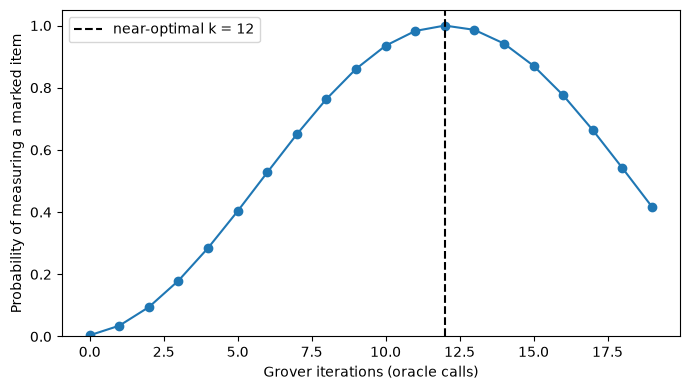

N=256, M=1: k=12, success=1.000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def grover_success_probability(items, marked, iterations):
    theta = np.arcsin(np.sqrt(marked / items))
    return np.sin((2 * iterations + 1) * theta) ** 2

items = 256
marked = 1
theta = np.arcsin(np.sqrt(marked / items))
iteration_counts = np.arange(0, 20)
success_probabilities = [
    grover_success_probability(items, marked, count)
    for count in iteration_counts
]
recommended_iterations = int(np.floor(np.pi / (4 * theta) - 0.5))

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(iteration_counts, success_probabilities, marker="o")
axis.axvline(recommended_iterations, color="black", linestyle="--", label=f"near-optimal k = {recommended_iterations}")
axis.set_xlabel("Grover iterations (oracle calls)")
axis.set_ylabel("Probability of measuring a marked item")
axis.set_ylim(0, 1.05)
axis.legend()
figure.tight_layout()
plt.show()
print(f"N={items}, M={marked}: k={recommended_iterations}, success={success_probabilities[recommended_iterations]:.3f}")

assert grover_success_probability(4, 1, 1) > 0.999999

### From query count to actual work

The $\Theta(\sqrt{N})$ result counts calls to the marking oracle. A practical implementation must also construct that oracle as a reversible circuit, uncompute temporary data, and run the circuit reliably. If one oracle call costs $C_f$ gates, a rough gate-count contribution is $\Theta(C_f\sqrt{N})$, plus state preparation, diffusion, error correction, and measurement. On a quantum processor, long circuits may require many physical operations per logical operation.

The advantage is most compelling when the oracle is compact and the task truly offers no exploitable structure to a classical algorithm. If the data must first be loaded from classical memory into a quantum state, that cost belongs in the comparison too.

## 4. Shor's algorithm: factoring becomes period finding

For an integer $N$ to factor, choose $a$ relatively prime to $N$ and study the periodic function $f(x)=a^x\bmod N$. Its period $r$ is the smallest positive integer with $a^r\equiv1\pmod N$. A quantum circuit creates a superposition over exponents, computes the modular powers reversibly, and uses the quantum Fourier transform (QFT) and measurement to obtain information about a fraction close to $s/r$. Classical continued fractions can use that sample to infer a candidate period.

For the earlier toy example, $N=15$ and $a=2$ give the cycle $1,2,4,8,1,\ldots$, so $r=4$. Since $r$ is even, $a^{r/2}=4$, and $\gcd(4-1,15)=3$ while $\gcd(4+1,15)=5$. A real implementation repeats the quantum sampling as needed and checks candidate factors classically.

If the input integer has $n=\lceil\log_2N\rceil$ bits, known fault-tolerant circuit constructions for factoring use a number of logical operations polynomial in $n$ (with resource counts depending on arithmetic circuits, precision, and architecture). The best-known classical factoring algorithms take subexponential time in $n$, not known polynomial time. No proof rules out a polynomial-time classical factoring algorithm, and factoring is not known to be NP-complete.

### Why the QFT is not simply a giant lookup table

The QFT on $2^n$ basis states is the transformation

$$|x\rangle\mapsto\frac{1}{\sqrt{2^n}}\sum_{y=0}^{2^n-1}e^{2\pi ixy/2^n}|y\rangle.$$

Its matrix has exponentially many entries, but its structure allows an exact circuit using $O(n^2)$ elementary gates, or an approximate circuit with fewer gates when small rotations can be omitted. This is a useful algorithmic lesson: a transformation can act on an exponentially large state space without explicitly writing down its full matrix. The circuit and the problem structure matter.

## 5. Complexity classes: what does BQP mean?

A **complexity class** groups decision problems according to the resources needed to solve them. Here are useful reference points:

- **P:** problems solvable by a deterministic classical algorithm in polynomial time.
- **BPP:** problems solvable by a randomized classical polynomial-time algorithm with error probability bounded below one half by a constant.
- **BQP:** problems solvable by a uniform family of polynomial-size quantum circuits with bounded error, conventionally at most $1/3$ on every input. Repetition and majority voting can reduce the error exponentially while increasing resources by a polynomial factor.
- **NP:** decision problems whose yes answers have certificates verifiable in deterministic polynomial time.

A quantum algorithm belongs to BQP when it solves its problem with bounded error using resources polynomial in the input length. BQP is a model of efficient quantum computation, not a promise that every problem in BQP is practically fast on current hardware. Uniformity also rules out hiding an arbitrary exponentially large circuit description in the algorithm family.

### Known relationships and open questions

Every deterministic polynomial-time computation can be run as a quantum computation, so $P\subseteq BQP$. Likewise, classical randomized polynomial-time computation is contained in BQP, so $BPP\subseteq BQP$. A standard upper bound is $BQP\subseteq PSPACE$, where PSPACE contains problems solvable with polynomial memory. These containments do not tell us whether any are strict.

The relationship between BQP and NP is unresolved. It is not known whether all of NP is in BQP, nor whether BQP is contained in NP. Shor's factoring algorithm shows that factoring is in BQP, but factoring is not known to be NP-complete. Claims that quantum computers efficiently solve every NP-complete problem are unsupported.

## 6. What counts as a quantum speedup?

A meaningful comparison identifies the same problem, input-size parameter, accuracy, success probability, and resource model for both classical and quantum methods. It should account for:

- the best known classical algorithm, not just a naive baseline;
- oracle construction and data loading;
- gate count, circuit depth, qubits, and classical post-processing;
- repetitions needed for the desired confidence;
- physical noise, error correction, and hardware overhead.

A theoretical asymptotic advantage and a practical wall-clock advantage are different claims. Quantum error correction can make long computations reliable, but encoding logical qubits and correcting errors require substantial physical resources. Small demonstrations illustrate principles; they do not by themselves show a useful speedup.

### A compact comparison

| Task or claim | Classical benchmark | Quantum result | Important qualification |
|---|---|---|---|
| Unstructured search, one marked item | $\Theta(N)$ queries | $\Theta(\sqrt{N})$ queries | Oracle calls are the measure; quadratic, not exponential, improvement |
| Deutsch-Jozsa promise problem | Exponential deterministic exact queries for general input size | One query | Bounded-error classical algorithms need only constant queries |
| Integer factoring | Best known is subexponential in input bits | Polynomial-time fault-tolerant quantum algorithm | No classical polynomial lower bound is known; hardware resources are large |
| Simulating quantum systems | Classical cost often grows rapidly with system size | Can represent and evolve quantum states natively | Advantage depends on model, precision, circuit depth, and the output requested |

## Try It

1. A search space grows from $N=10^4$ to $N=10^8$. Compare the query counts predicted by classical exhaustive search and Grover search for one marked item. What is the speedup factor in each case?
2. Explain why a one-query Deutsch-Jozsa algorithm does not establish an exponential advantage over bounded-error classical algorithms.
3. If one Grover oracle call requires 500 elementary gates, estimate the oracle-related gate count for $N=10^6$ and one marked item using $\frac{\pi}{4}\sqrt{N}$ calls. What important costs are omitted?
4. Factoring a $2^n$-scale integer in time polynomial in $n$ is very different from polynomial in the integer's value. Explain why, and state what is and is not known about classical factoring complexity.
5. Is the statement 'quantum computers solve NP-complete problems efficiently' established? Use the known relationship between BQP and NP in your answer.
6. Name at least three costs that a query-complexity comparison can omit when estimating practical runtime.

## Answers

1. Classical exhaustive search uses up to $10^4$ and $10^8$ queries, respectively. Grover uses about $\frac{\pi}{4}\sqrt{N}$, or roughly 79 and 7,854 queries. The classical-to-quantum query ratios are approximately 127 and 12,732, reflecting $\Theta(\sqrt{N})$ scaling. These are query estimates, not complete runtime estimates.

2. The exponential separation compares quantum query complexity with deterministic exact classical query complexity under a promise. A bounded-error randomized classical algorithm can distinguish constant from balanced functions with a constant number of queries, so the exponential gap does not hold against that model.

3. The query estimate is about $\frac{\pi}{4}\sqrt{10^6}\approx785$ calls. At 500 gates each, this is about 392,500 oracle-related gates. It omits diffusion gates, state preparation, workspace and uncomputation, error correction, routing, measurement, and any cost of constructing or loading the oracle.

4. An integer with about $n$ bits has value around $2^n$, so a runtime polynomial in $n$ is exponentially smaller than a runtime polynomial in the integer's value. Shor gives a polynomial-time quantum factoring algorithm in the bit length under the fault-tolerant model. The best known classical algorithm is subexponential, but no proof excludes a classical polynomial-time factoring algorithm.

5. No. The relationship between BQP and NP is unknown. Shor factors integers efficiently, but factoring is not known to be NP-complete, and there is no established general efficient quantum algorithm for NP-complete problems.

6. Examples include oracle implementation, classical-to-quantum data loading, reversible workspace and uncomputation, error correction, gate connectivity/routing, measurement repetitions, classical post-processing, and hardware execution time.

## Summary

Algorithm analysis begins by defining input size, success criteria, and the resource being counted. Grover's algorithm gives a provably optimal quadratic improvement for unstructured search in the oracle model. Deutsch-Jozsa shows how promises and error models change comparisons. Shor places factoring in BQP through period finding, but does not prove classical factoring is hard or that NP-complete problems are efficiently solvable quantumly.

The broad lesson from all three notebooks is that quantum algorithms use amplitudes, phase, and interference to solve particular problems with particular resource advantages. State-space size alone does not establish a speedup; careful algorithm analysis and a fair classical comparison do.